<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [15]:
!pip install pandas 
!pip install matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-01-08 18:45:40--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  38.3MB/s    in 3.8s    

2026-01-08 18:45:44 (39.8 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


In [19]:
len(df)

65437

In [20]:
df_bubble[['Age', 'SOPartFreq']].value_counts().head()


Age              SOPartFreq           
25-34 years old  A few times per week     493
35-44 years old  A few times per week     446
25-34 years old  Daily or almost daily    216
45-54 years old  A few times per week     182
35-44 years old  Daily or almost daily    168
Name: count, dtype: int64

In [9]:
#whats in SOPartFreq
df['SOPartFreq'].value_counts()

SOPartFreq
Less than once per month or monthly                   24162
I have never participated in Q&A on Stack Overflow    11143
A few times per month or weekly                        6277
A few times per week                                   2278
Daily or almost daily                                   936
Multiple times per day                                  441
Name: count, dtype: int64

In [10]:
#prepare and clean the data
df_bubble = df[['Age', 'SOPartFreq', 'JobSat']].copy()

# Remove unusable rows
df_bubble = df_bubble[
    (df_bubble['Age'].notna()) &
    (df_bubble['Age'] != 'Prefer not to say') &
    (df_bubble['SOPartFreq'].notna()) &
    (df_bubble['JobSat'].notna())
].copy()

In [17]:
df_bubble[['Age', 'SOPartFreq']].value_counts().head()


Age              SOPartFreq           
25-34 years old  A few times per week     493
35-44 years old  A few times per week     446
25-34 years old  Daily or almost daily    216
45-54 years old  A few times per week     182
35-44 years old  Daily or almost daily    168
Name: count, dtype: int64

In [18]:
len(df_bubble)


1862

In [11]:
#convert age to numeric
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df_bubble['Age_numeric'] = df_bubble['Age'].map(age_mapping)


In [12]:
#convert participation frequency to numeric
sopartfreq_mapping = {
    'Never': 0,
    'Less than once per month': 1,
    'Once per month': 2,
    'A few times per month': 3,
    'Once per week': 4,
    'A few times per week': 5,
    'Daily or almost daily': 6
}

df_bubble['SOPartFreq_numeric'] = df_bubble['SOPartFreq'].map(sopartfreq_mapping)


In [13]:
#Convert JobSat to numeric and clean
df_bubble['JobSat'] = pd.to_numeric(df_bubble['JobSat'], errors='coerce')

df_bubble = df_bubble.dropna(subset=['Age_numeric', 'SOPartFreq_numeric', 'JobSat']).copy()


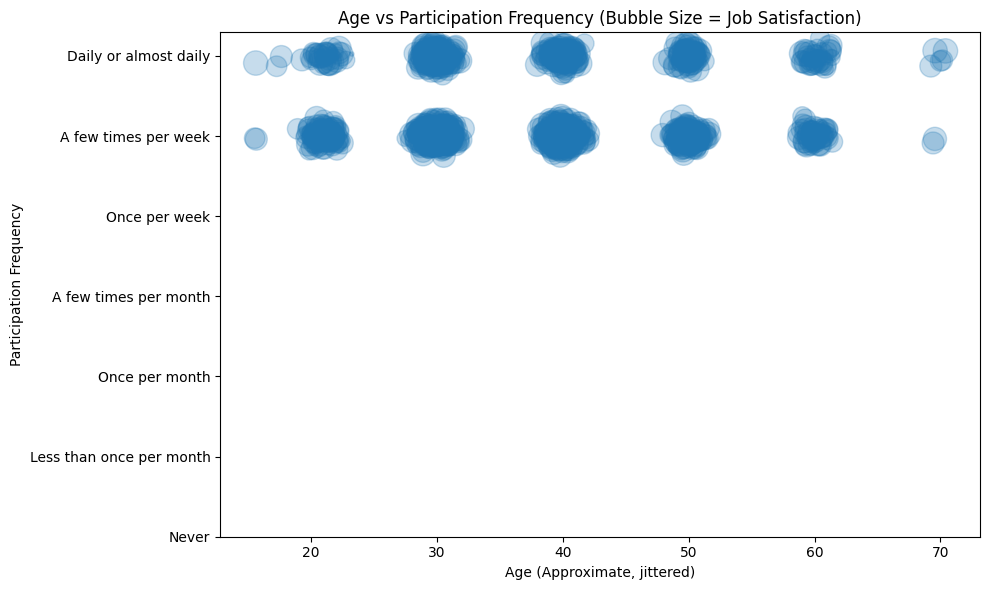

Rows plotted: 1862
Age              SOPartFreq           
25-34 years old  A few times per week     493
35-44 years old  A few times per week     446
25-34 years old  Daily or almost daily    216
45-54 years old  A few times per week     182
35-44 years old  Daily or almost daily    168
18-24 years old  A few times per week     127
45-54 years old  Daily or almost daily     89
55-64 years old  A few times per week      58
18-24 years old  Daily or almost daily     36
55-64 years old  Daily or almost daily     35
Name: count, dtype: int64


In [16]:
#create bubble plot
rng = np.random.default_rng(42)
x = df_bubble['Age_numeric'] + rng.normal(0, 0.7, size=len(df_bubble))          # small horizontal jitter
y = df_bubble['SOPartFreq_numeric'] + rng.normal(0, 0.08, size=len(df_bubble))  # tiny vertical jitter

# Bubble sizes: scale JobSat to something visible but not insane
sizes = ((df_bubble['JobSat'] / df_bubble['JobSat'].max()) * 300) + 10

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=sizes, alpha=0.25)

plt.xlabel('Age (Approximate, jittered)')
plt.ylabel('Participation Frequency')
plt.title('Age vs Participation Frequency (Bubble Size = Job Satisfaction)')

plt.yticks(
    ticks=list(sopartfreq_mapping.values()),
    labels=list(sopartfreq_mapping.keys())
)

plt.tight_layout()
plt.show()

print("Rows plotted:", len(df_bubble))
print(df_bubble[['Age', 'SOPartFreq']].value_counts().head(10))


#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


In [21]:
#select data
df_bubble = df[
    ['ConvertedCompYearly', 'JobSat', 'Age']
].copy()


In [22]:
#clean data
df_bubble = df_bubble[
    df_bubble['ConvertedCompYearly'].notna() &
    df_bubble['JobSat'].notna() &
    df_bubble['Age'].notna() &
    (df_bubble['Age'] != 'Prefer not to say')
].copy()


In [29]:
#create age groups
df_bubble['AgeGroup'] = df_bubble['Age'].map({
    '18-24 years old': '18–24',
    '25-34 years old': '25–34',
    '35-44 years old': '35–44',
    '45-54 years old': '45–54',
    '55-64 years old': '55–64',
    '65 years or older': '65+'
})

df_bubble = df_bubble.dropna(subset=['AgeGroup'])


In [30]:
#Stratified sampling by age
sampled = (
    df_bubble
    .groupby('AgeGroup', group_keys=False)
    .apply(lambda x: x.sample(
        n=min(800, len(x)), random_state=42
    ))
)

/tmp/ipykernel_2650/56060933.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [31]:
#conver numeric columns
df_bubble['ConvertedCompYearly'] = pd.to_numeric(
    df_bubble['ConvertedCompYearly'], errors='coerce'
)
df_bubble['JobSat'] = pd.to_numeric(
    df_bubble['JobSat'], errors='coerce'
)

df_bubble = df_bubble.dropna(
    subset=['ConvertedCompYearly', 'JobSat']
)


/tmp/ipykernel_2650/151042452.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bubble['ConvertedCompYearly'] = pd.to_numeric(
/tmp/ipykernel_2650/151042452.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bubble['JobSat'] = pd.to_numeric(


In [32]:
#trim outliers
Q1 = df_bubble['ConvertedCompYearly'].quantile(0.25)
Q3 = df_bubble['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

df_bubble = df_bubble[
    df_bubble['ConvertedCompYearly'] <= upper
].copy()


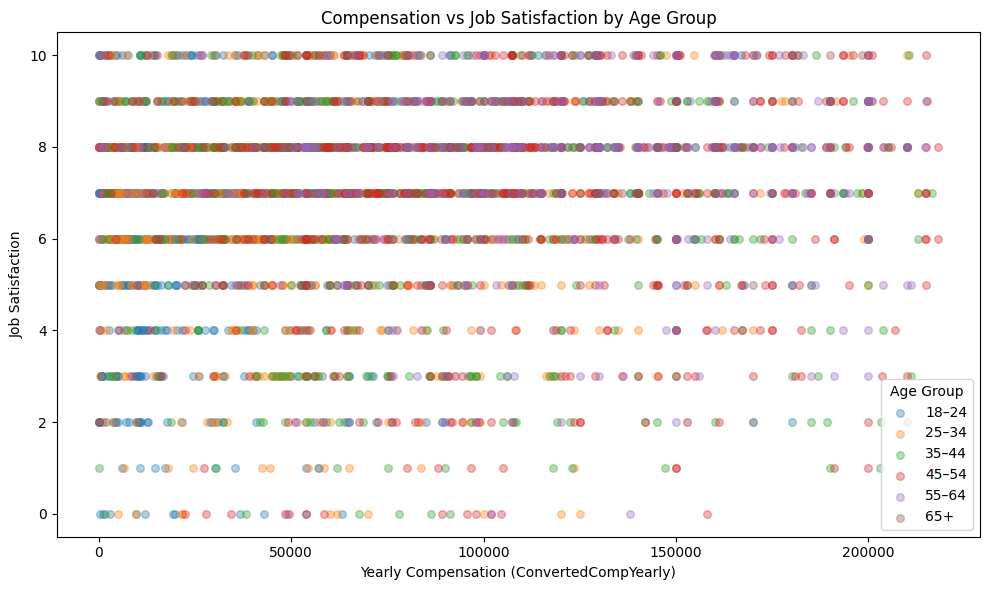

In [35]:
#create plot
plt.figure(figsize=(10, 6))

for group, gdf in sampled.groupby('AgeGroup'):
    plt.scatter(
        gdf['ConvertedCompYearly'],
        gdf['JobSat'],
        alpha=0.35,
        label=group,
        s=30
    )

plt.xlabel('Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction')
plt.title('Compensation vs Job Satisfaction by Age Group')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()


### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



In [38]:
#Prepare and clean data/Make age groups
df_lang = df[['Age', 'LanguageHaveWorkedWith']].copy()

# Remove unusable rows
df_lang = df_lang[
    df_lang['Age'].notna() &
    (df_lang['Age'] != 'Prefer not to say') &
    df_lang['LanguageHaveWorkedWith'].notna()
].copy()

age_map = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18–24',
    '25-34 years old': '25–34',
    '35-44 years old': '35–44',
    '45-54 years old': '45–54',
    '55-64 years old': '55–64',
    '65 years or older': '65+'
}
df_lang['AgeGroup'] = df_lang['Age'].map(age_map)
df_lang = df_lang.dropna(subset=['AgeGroup']).copy()

In [39]:
#Split languages
df_lang['Language'] = df_lang['LanguageHaveWorkedWith'].str.split(';')
df_lang = df_lang.explode('Language')
df_lang['Language'] = df_lang['Language'].str.strip()
df_lang = df_lang.dropna(subset=['Language'])


In [40]:
#pic top languages
top_n = 20
top_langs = df_lang['Language'].value_counts().head(top_n).index

df_lang_top = df_lang[df_lang['Language'].isin(top_langs)].copy()


In [41]:
#count frequency
counts = (
    df_lang_top
    .groupby(['AgeGroup', 'Language'])
    .size()
    .reset_index(name='Count')
)


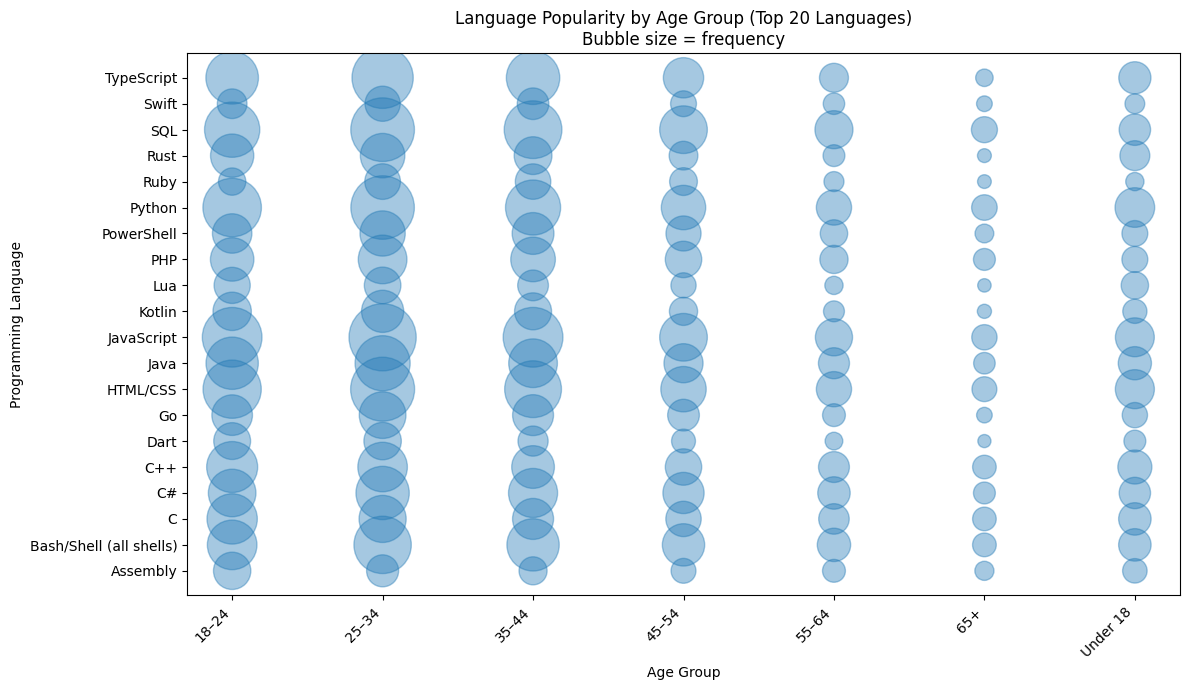

In [42]:
import numpy as np

plt.figure(figsize=(12, 7))

sizes = np.sqrt(counts['Count']) * 20  # scale factor you can tweak

plt.scatter(
    counts['AgeGroup'],
    counts['Language'],
    s=sizes,
    alpha=0.4
)

plt.xlabel('Age Group')
plt.ylabel('Programming Language')
plt.title(f'Language Popularity by Age Group (Top {top_n} Languages)\nBubble size = frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [50]:
#Prepare and clean data
df_db_js = df[['DatabaseWantToWorkWith', 'JobSat']].copy()

df_db_js = df_db_js[
    df_db_js['DatabaseWantToWorkWith'].notna() &
    df_db_js['JobSat'].notna()
].copy()

df_db_js['JobSat'] = pd.to_numeric(df_db_js['JobSat'], errors='coerce')
df_db_js = df_db_js.dropna(subset=['JobSat'])


In [51]:
#split and explode databases
df_db_js['DatabaseWantToWorkWith'] = df_db_js['DatabaseWantToWorkWith'].str.split(';')
df_db_js = df_db_js.explode('DatabaseWantToWorkWith')


In [52]:
bubble_data = (
    df_db_js
    .groupby(['DatabaseWantToWorkWith', 'JobSat'])
    .size()
    .reset_index(name='Count')
)


In [53]:
#Limit to top databases
top_dbs = (
    bubble_data.groupby('DatabaseWantToWorkWith')['Count']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

bubble_data = bubble_data[bubble_data['DatabaseWantToWorkWith'].isin(top_dbs)]


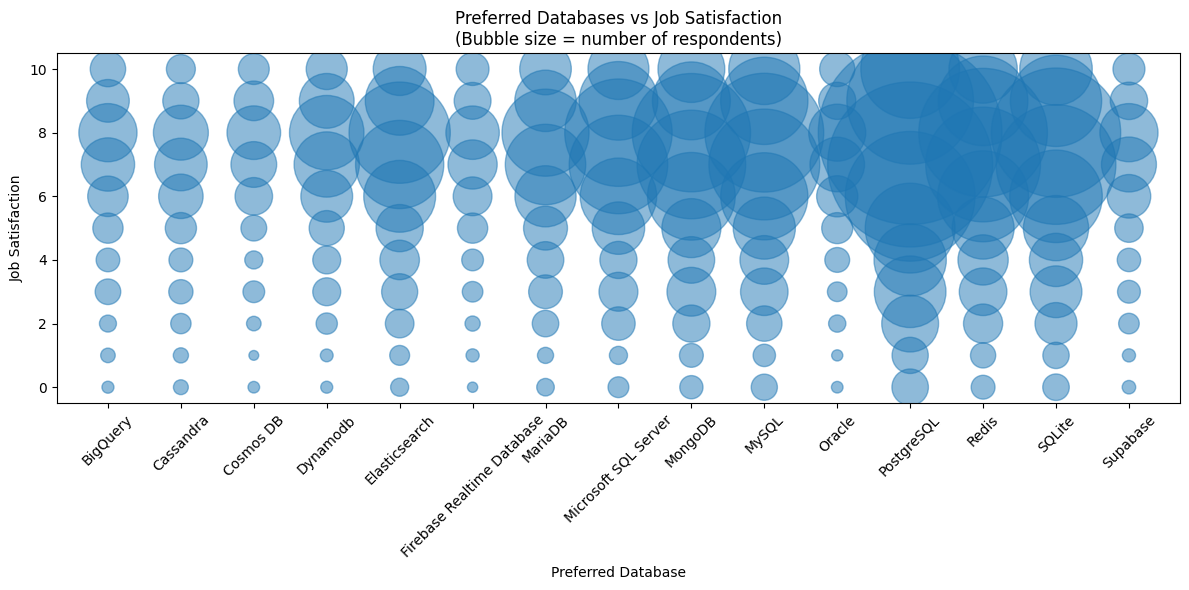

In [54]:
#bubble plots
plt.figure(figsize=(12, 6))

plt.scatter(
    bubble_data['DatabaseWantToWorkWith'],
    bubble_data['JobSat'],
    s=bubble_data['Count'] * 5,   # scale bubble size
    alpha=0.5
)

plt.xlabel('Preferred Database')
plt.ylabel('Job Satisfaction')
plt.title('Preferred Databases vs Job Satisfaction\n(Bubble size = number of respondents)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [ ]:
##Write your code here

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



In [ ]:
##Write your code here

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



In [ ]:
##Write your code here

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
